In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import haccytrees.mergertrees
import pandas as pd
import seaborn as sns
%load_ext line_profiler
%reload_ext autoreload
%autoreload 1
%aimport help_func_haccytrees
plt.rc('figure', facecolor='w')

pyfftw not available, using numpy fft


## Fit individual MAHs (of FGs)

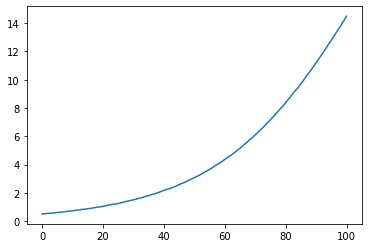

In [2]:
from diffmah.diffmah.fit_mah_helpers import mse_loss_variable_mp_x0, get_loss_data_variable_mp_x0
from diffmah.diffmah.individual_halo_assembly import _get_params_from_u_params
from diffmah.diffmah.individual_halo_assembly import _calc_halo_history
from diffmah.diffmah.utils import jax_adam_wrapper
simulation = haccytrees.Simulation.simulations['LastJourney'] # read in a chunk of simulation
cosmic_time = simulation.cosmo.lookback_time(1e-10) - simulation.step2lookback(np.array(simulation.cosmotools_steps))
fig, ax = plt.subplots()
ax.plot(cosmic_time) # cosmic time vs timesteps

## Parameter Distributions

### Helper Function

In [3]:
# Calculate their parameters
def calc_subset_params(mainbranch_peakmass, size, cosmic_time, tpeak, min_mass, non_fg_failed_violent):

    subset_params = np.zeros((size, 5))
    
    for ihalo in range(size):
        p_init, loss_data = get_loss_data_variable_mp_x0(
            cosmic_time, 
            np.log10(mainbranch_peakmass[ihalo]), 
            tpeak[ihalo], 
            np.log10(min_mass)
        )
        n_step = 150
        _res = jax_adam_wrapper(mse_loss_variable_mp_x0, p_init, loss_data, n_step, n_warmup=2)
        p_best, loss, loss_arr, params_arr, fit_terminates = _res # This is minimization of loss
        logmp_fit, u_x0, u_early, u_dy = p_best                   # Pull out the info
        #print(logmp_fit)
        logt_target, log_mah_target, logtmp, u_k = loss_data
        x0, k, early, late = _get_params_from_u_params(u_x0, u_k, u_early, u_dy)
        logt_fit = np.linspace(0, 1.15, 500)                      # Specify the range of where you would like to fit
        dmhdt_fit, log_mah_fit = _calc_halo_history(logt_fit, np.log10(tpeak[ihalo]), logmp_fit, x0, k, early, late) # What is this?
        subset_params[ihalo,:] = [logmp_fit, tpeak[ihalo], early, late, non_fg_failed_violent[ihalo]]
    return subset_params

### Implementation

In [4]:
# Load haccytrees data
forest, progenitor_array = haccytrees.mergertrees.read_forest(
    "/data/a/cpac/mbuehlmann/LastJourney/forest/m000p.forest.000.hdf5", 'LastJourney', 
    nchunks=10, 
    chunknum=0, 
    mass_threshold=1e11
)
z0_mask = forest['snapnum'] == 100
mlim = [1e13, 4e13]
target_mask = z0_mask \
              & (forest['tree_node_mass'] > mlim[0]) \
              & (forest['tree_node_mass'] < mlim[1])
target_idx = forest['halo_index'][target_mask]
print(len(target_idx)) # This seems low. What is different from normal?

3392


In [5]:
# Go find some fossil groups!
absolute_threshold = True
threshold = 5e11
z_thresh = 1
mlim = [1e13, 10**14.5] # We're going to go ahead and call this a "very thin mass bin," so that we can treat M_0 as constant
target_idx = help_func_haccytrees.find_halos(forest, mlim)
mainbranch_index, mainbranch_masses = help_func_haccytrees.get_branches(target_idx, forest)
mainbranch_mergers = help_func_haccytrees.get_mainbranch_mergers(forest, progenitor_array, mainbranch_index, absolute_threshold)
major_mergers = help_func_haccytrees.get_major_mergers(mainbranch_mergers, threshold)
lmm_redshift, lmm_index = help_func_haccytrees.get_lmms(major_mergers, threshold)
fgs, failed, violent = help_func_haccytrees.find_specials(forest, mainbranch_index, major_mergers, lmm_redshift, target_idx, z_thresh, violent_thresh = 20)
print(len(fgs))
print(len(failed))
print(failed)

mainbranch_index shape:  (4225, 101)
main_merger_index shape:  (331614,)
210
15
[   62872   269678  1197748  1956570  2638021  3121367  3340366  4570713
  4647781  5980362  6402227  7335831 12189738 12444377 14552661]


In [86]:
# find the mass range of fgs and failed groups
merging_mask = lmm_redshift > z_thresh
failures_mask = lmm_redshift == -1
min_min = np.min((np.min(mainbranch_masses[:, -1][merging_mask]), np.min(mainbranch_masses[:, -1][failures_mask])))
max_max = np.max((np.max(mainbranch_masses[:, -1][merging_mask]), np.max(mainbranch_masses[:, -1][failures_mask])))
mlims = np.array([min_min, max_max])
print(mlims)

# Use that to go find violent groups
violent_idx, mass_mask = help_func_haccytrees.find_violent(mainbranch_masses, mlims, major_mergers, mainbranch_index, violent_thresh = 0.1)
print(mass_mask.shape)
#print(violent_mask.shape)
#print(violent_mask[violent_mask].shape)
print(violent_idx)

[1.0024475e+13 6.4190333e+13]
8.0 15.0
(4225,)
[12492240  2715790 12572449  8117638  7610127 12903315 11206417  7033618
  7066393  7076281 13217303  7093611  4208662 11256497  1791203  7410741
  9661160  9600086  7428566 12905599 13195547 12437158 11348412  8223825
 11958178  2494843 11944123 11401103  2498737  8786002  2466338  8906576
  9002200  2523544  2581119  9042128 11768916  9043927  8995379  2462127
  9330998  8710408 12416373  8299889  8300929  8309345  2262619  8540070
  3541076 12312502 12273926 12261542  8639943  8683422 12244773  2409118
 12131794 13269707  3574964  9130282  6966575 10725686  1164370 14396278
  1207566 10259868 14299865 10295416  2954095 10242206  2930675  4943753
  6035367  1349620  6967763  4984633  6050475 14563032  5597030 15011343
 10434633 10623975  5393712 14881064 14824281  3109674  5180629 10659707
  5156508 10405108  5145672  1089195  5594726  5445496 10805171 14119316
 10870900 13600061  3368559 13592294  6678331 13589389 11102321 10223516
  68

# Take a quick look at violent (or social butterfly?) groups

4225
4225


Text(0, 0.5, 'count')

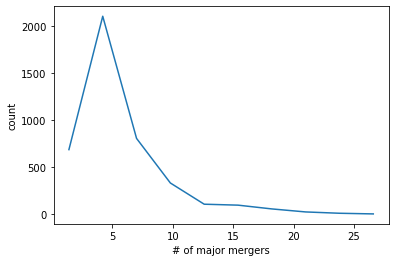

In [8]:
# How many major mergers is a normal amount?
print(len(target_idx))
print(len(major_mergers))
mergers_count = np.zeros(len(major_mergers))
for i in range(len(major_mergers)):
    mask = major_mergers[i] > 0
    mergers_count[i] = len(major_mergers[i][mask])
mergers_count
hist = np.histogram(mergers_count)
bin_centers = (hist[1][:-1] + hist[1][1:])/2
fig, ax = plt.subplots()
ax.plot(bin_centers, hist[0])
ax.set_xlabel("# of major mergers")
ax.set_ylabel("count")

In [9]:
threshold = 20
violent_mask = mergers_count > threshold
print(mergers_count.shape)
print(violent_mask)
violent_idx = np.nonzero(violent_mask)[0] # Weird that I have to do this??
violent = mainbranch_index[:,-1][violent_idx]
print(type(violent))
print(len(violent))
print(violent)

(4225,)
[False False False ... False False False]
<class 'numpy.ndarray'>
26
[ 1026909  2101386  2229593  2722813  3937152  4832978  6009986  6667247
  6974371  7212571  7508919  7914677  7986603  8955216  9203044  9210548
  9944736 12112932 12379179 12851049 13535712 13824972 13961781 14941871
 15174314 16985163]


In [10]:
violent_thresh = threshold
#print([major_mergers[i][major_mergers[i] > 0] for i in range(len(major_mergers))])
print(len([major_mergers[i][major_mergers[i] > 0] for i in range(len(major_mergers))]))
violent_mask = len([major_mergers[i][major_mergers[i] > 0] for i in range(len(major_mergers))]) > violent_thresh
print(violent_mask)

4225
True


In [11]:
%%time
# Check out the MAH's of these violent groups
absolute_threshold = True
threshold = 5e11
z_thresh = 1
# Two ways to do this
approach_1 = True
if approach_1:
    v_mainbranch_index, v_mainbranch_masses = help_func_haccytrees.get_branches(violent, forest)
    v_mainbranch_mergers = help_func_haccytrees.get_mainbranch_mergers(forest, progenitor_array, v_mainbranch_index, absolute_threshold)
    v_major_mergers = help_func_haccytrees.get_major_mergers(v_mainbranch_mergers, threshold)
else:
    v_mainbranch_index = mainbranch_index[violent_idx]
    v_mainbranch_masses = mainbranch_masses[violent_idx]
    v_mainbranch_mergers = mainbranch_mergers[violent_idx]
    v_major_mergers = major_mergers[violent_idx]

v_mainbranch_peakmass = np.maximum.accumulate(v_mainbranch_masses, axis=1) # convert a mass matrix of shape (nhalos, nsteps) to peakmass 
tpeak = cosmic_time[np.argmax(v_mainbranch_peakmass, axis=1)]
min_mass = 100*simulation.particle_mass

CPU times: user 30.5 ms, sys: 9.04 ms, total: 39.6 ms
Wall time: 2.14 ms


/home/acossairt/miniconda3/envs/fossil_groups_env/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in log10
  import sys
/home/acossairt/miniconda3/envs/fossil_groups_env/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in log10


Text(0.5, 0, 'log(cosmic_time)')

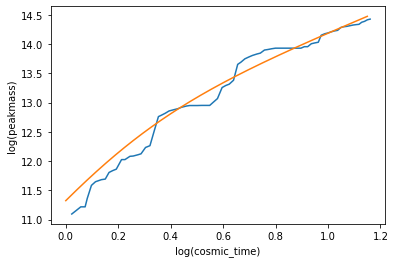

In [131]:
#ihalo = violent[1] # This picks the halo you want (# in the index)
ihalo = 1 # 2 is very weird, as is 0
#print(v_mainbranch_masses[ihalo])
#print(v_major_mergers[ihalo])
p_init, loss_data = get_loss_data_variable_mp_x0(
    cosmic_time, 
    np.log10(v_mainbranch_peakmass[ihalo]), 
    tpeak[ihalo], 
    np.log10(min_mass)
)
n_step = 150
_res = jax_adam_wrapper(mse_loss_variable_mp_x0, p_init, loss_data, n_step, n_warmup=2)
p_best, loss, loss_arr, params_arr, fit_terminates = _res # This is minimization of loss
logmp_fit, u_x0, u_early, u_dy = p_best                   # Pull out the info
logt_target, log_mah_target, logtmp, u_k = loss_data
x0, k, early, late = _get_params_from_u_params(u_x0, u_k, u_early, u_dy)
logt_fit = np.linspace(0, 1.15, 500)                      # Specify the range of where you would like to fit
dmhdt_fit, log_mah_fit = _calc_halo_history(logt_fit, np.log10(tpeak[ihalo]), logmp_fit, x0, k, early, late) # What is this?

fig, ax = plt.subplots(1, 1)
ax.plot(np.log10(cosmic_time), np.log10(v_mainbranch_peakmass[ihalo]))
#ax.plot(cosmic_time, mainbranch_peakmass[ihalo]) # What's it like without logs? (like a normal MAH but monotonic)
ax.plot(logt_fit, log_mah_fit)
#ax.set(xlim=(0.4, 1.2), ylim=(11.8, 13.5))
ax.set_ylabel("log(peakmass)")
ax.set_xlabel("log(cosmic_time)")

# Multi-sample

In [77]:
# Grab a sample of fgs, non-fgs, failed, and violent groups
all_nonfgs = target_idx[~np.isin(target_idx, fgs)]
#print(all_nonfgs)
nonfgs = np.delete(all_nonfgs, np.concatenate((np.argwhere(np.isin(all_nonfgs, failed)), np.argwhere(np.isin(all_nonfgs, violent_idx))))) # nonfgs that are also not failed groups and also not violent
size = 1000
fg_count = len(fgs)
failed_count = len(failed)
violent_count = 100 #len(violent_idx)
nonfg_count = size - fg_count - failed_count - violent_count
np.random.seed(0)
subset = np.concatenate((np.random.choice(nonfgs, nonfg_count), np.random.choice(fgs, fg_count), np.random.choice(failed, failed_count), np.random.choice(violent_idx, violent_count)))

# Identify fgs, non-fgs, and failed groups
# Is there an easier way to do this? Since they are concatenated in order?
fg_tf = np.isin(subset, fgs)
non_fg_failed_violent = np.where(np.isin(subset, failed), 2, fg_tf)
non_fg_failed_violent = np.where(np.isin(subset, violent_idx), 3, non_fg_failed_violent)
#print(non_fg_failed_violent)

# Check if that worked
print(len(non_fg_failed_violent[non_fg_failed_violent == 0]), " vs. ", nonfg_count)
print(len(non_fg_failed_violent[non_fg_failed_violent == 1]), " vs. ", fg_count)
print(len(non_fg_failed_violent[non_fg_failed_violent == 2]), " vs. ", failed_count)
print(len(non_fg_failed_violent[non_fg_failed_violent == 3]), " vs. ", violent_count)

675  vs.  675
210  vs.  210
15  vs.  15
100  vs.  100


In [78]:
# Find the peakmasses of all these halos
ss_mainbranch_index, ss_mainbranch_masses = help_func_haccytrees.get_branches(subset, forest)
ss_mainbranch_peakmass = np.maximum.accumulate(ss_mainbranch_masses, axis=1) # convert a mass matrix of shape (nhalos, nsteps) to peakmass
tpeak = cosmic_time[np.argmax(ss_mainbranch_peakmass, axis=1)] # Go check out this part
min_mass = 100*simulation.particle_mass

mainbranch_index shape:  (1000, 101)


In [79]:
%%time
# Calculate params for all halos
all_subset_params = calc_subset_params(ss_mainbranch_peakmass, size, cosmic_time, tpeak, min_mass, non_fg_failed_violent)

/home/acossairt/miniconda3/envs/fossil_groups_env/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in log10
  if __name__ == '__main__':


CPU times: user 23min 59s, sys: 2min 31s, total: 26min 30s
Wall time: 21min 42s


In [149]:
# If these are effectively the same, why do I use the second version?
#print(all_subset_params[:,4])
#print([int(i) for i in all_subset_params[:,4]])

In [80]:
# Pickle those results
# Is this right? And could I just make it using param_names?
param_dict = {"final_mass" : all_subset_params[:,0], "tpeak": all_subset_params[:,1], "alpha_early": all_subset_params[:,2], "alpha_late": all_subset_params[:,3], "non_fg_failed_violent": [int(i) for i in all_subset_params[:,4]]}

# Old way
param_names = ["final_mass", "tpeak", "alpha_early", "alpha_late", "non_fg_failed_violent"]
df = pd.DataFrame(all_subset_params, index = subset, columns = param_names)

# Pickle the dictionary
pickle.dump(param_dict, open( "save.p", "wb" )) # Is that protocol correct?

In [81]:
pickled_params = pickle.load( open( "save.p", "rb" ) )

In [82]:
# Then divide into mass bins
pickled_params['mass_bin'] = np.zeros_like(pickled_params['final_mass']) # Is there a better way to do this? # Why are there some zeros?
mlims = [13, 13.5, 14, 14.5]
for i in range(len(mlims) - 1):
    mask = np.where(np.logical_and(pickled_params['final_mass'] > mlims[i], pickled_params['final_mass'] < mlims[i+1]))
    #print(mask) # Gives actual indices
    pickled_params['mass_bin'][mask] = i + 1
#pickled_params['mass_bin']

### Next steps
- Sample a couple hundred randomly selected halos at this range of masses [13, 13.5, 14, 14.5]
- Compare fossil MAH's to a a logmp-distribution-matched sample of non-fossils (because MAH parameters vary considerably with logmp)

### Plot

KeyError: 'non_fg_failed'

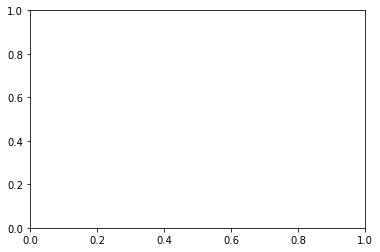

In [147]:
# Single plot (dictionary)
# Pick what to compare
param_names = ["final_mass", "tpeak", "alpha_early", "alpha_late", "non_fg_failed_violent", "mass_bin"]
x_param = 2
y_param = 3
markers = np.array(['o', 'X', 'd'])
#print(markers[pickled_params['non_fg_failed'][0]]) # I guess I would have to iterate over different lists?

# Single panel
fig, ax = plt.subplots()
scatter = ax.scatter(pickled_params[param_names[x_param]], pickled_params[param_names[y_param]], c = pickled_params[param_names[-1]], marker = markers[pickled_params['non_fg_failed']]) # Why is tpeak (subset_params[:, 1]) always the same? Or almost always the same...
#ax.set_xlim(np.min(pickled_params[param_names[x_param]]) - 0.5, np.max(pickled_params[param_names[x_param]]) + 0.5)
#ax.set_ylim(np.min(pickled_params[param_names[y_param]]) - 0.5, np.max(pickled_params[param_names[x_param]]) + 0.5)
ax.set_xlabel(param_names[x_param])
ax.set_ylabel(param_names[y_param])

# Compare to diagonal
#lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
#ax.plot(lims, lims)

# Unnecessarily complicated legend
labels = np.unique(pickled_params[param_names[-1]])
labels = [str(i) for i in labels]
plt.legend(handles=scatter.legend_elements()[0], labels=labels)

#fig.savefig(param_names[x_param] + "_vs_" + param_names[y_param] + ".png")

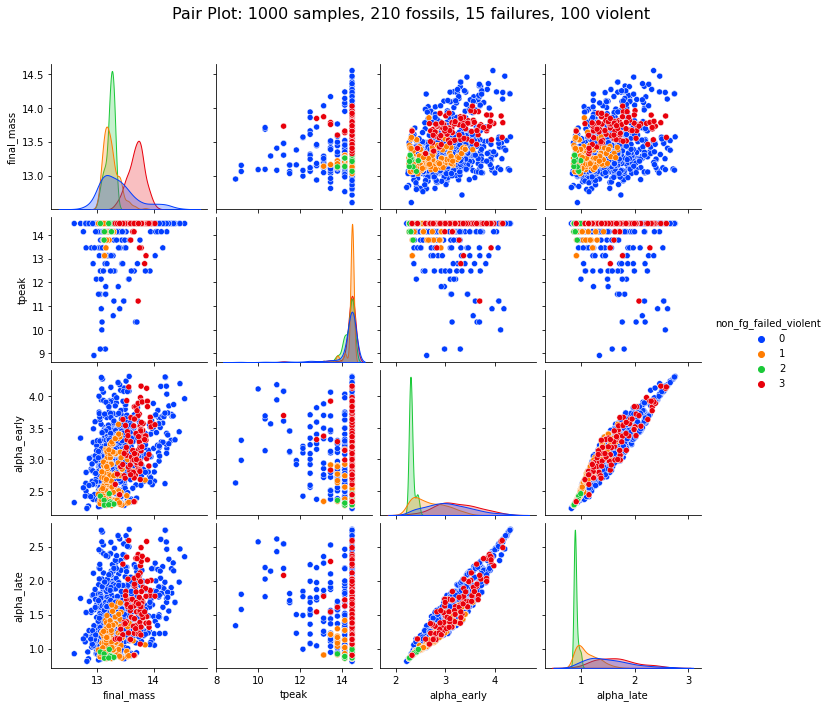

In [83]:
# For my data, penguin plots
param_names = ["final_mass", "tpeak", "alpha_early", "alpha_late", "non_fg_failed_violent"]
df = pd.DataFrame(pickled_params, index = subset, columns = param_names)
#print(df)
set_hue = True # True yields lots of errors
if set_hue:
    fig = sns.pairplot(df, hue="non_fg_failed_violent", palette = 'bright', diag_kws =  {'common_norm': False}) #marker
    fig.fig.suptitle("Pair Plot: " + str(size) + " samples, " + str(fg_count) + " fossils, " + str(failed_count) + " failures, " + str(violent_count) + " violent", fontsize = 16)
    fig.fig.subplots_adjust(top=0.9)
    fig.savefig("pair_plot_hue" + str(size) + "_violent.png")
else:
    fig = sns.pairplot(df)
    fig.fig.suptitle("Pair Plot: " + str(size) + " samples, " + str(fg_count) + " fossils", fontsize = 16)
    fig.fig.subplots_adjust(top=0.9)
    fig.savefig("pair_plot" + str(size) + "_violent.png")
    
# How did this even find halos with that high of mass?? My mlims were 1e13 and 4e13...